# Notebook 02 — Exploratory Data Analysis


## Project Context

Procurement organizations generate large volumes of operational data describing supplier performance, purchasing activities and contract execution.

Understanding these operations is essential for identifying procurement risks, evaluating supplier performance and supporting informed purchasing decisions.

This notebook explores the synthetic procurement dataset from both a business and analytical perspective. The objective is to assess data quality, understand procurement operations and identify the business variables that may support subsequent predictive analysis.

## Notebook Objectives

The objectives of this notebook are to:

- understand the structure of the procurement dataset;
- assess the overall quality and consistency of the data;
- explore procurement activities through key business indicators;
- identify operational patterns across suppliers and purchasing categories;
- summarize the business insights that will support the next stage of the project.

In [53]:
from pathlib import Path

import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
RAW_DATA_DIR = Path("../data/raw").resolve()

csv_file = next(RAW_DATA_DIR.glob("*.csv"))

procurement_df = pd.read_csv(csv_file)

## Procurement Dataset Overview

## Understand the Dataset

Before assessing data quality or exploring procurement performance, it is important to understand the structure of the dataset.

This section provides a high-level overview of the procurement data, helping us identify the available business information and the variables that may support subsequent analyses.

In [32]:
print(f"Purchase Orders : {procurement_df.shape[0]:,}")
print(f"Variables       : {procurement_df.shape[1]}")
print(f"Suppliers       : {procurement_df['Supplier'].nunique()}")
print(f"Item Categories : {procurement_df['Item_Category'].nunique()}")

Purchase Orders : 10,000
Variables       : 11
Suppliers       : 50
Item Categories : 10


In [33]:
procurement_df.head()

,PO_ID,Supplier,Item_Category,Order_Status,Order_Date,Delivery_Date,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Compliance
0,1,RailEngine,Body Structures,Delivered,2023-01-20,2023-03-21,141,7.62,5.11,6,1
1,2,MechaPrime,Bogies & Wheelsets,Delivered,2023-04-28,2023-07-10,418,123.54,87.66,76,1
2,3,RailCom,HVAC Systems,Delivered,2023-12-29,2024-04-24,328,260.42,177.91,8,1
3,4,RailMotion,Doors & Access Systems,Delivered,2023-05-08,2023-08-31,281,358.23,337.02,42,1
4,5,ElectroParts,Brake Systems,Delivered,2023-10-05,2024-01-05,91,397.81,318.06,15,1


### Initial Observation

The dataset contains 10,000 procurement transactions across 50 suppliers and 10 purchasing categories.

Each record represents an individual purchase order and includes commercial, operational and quality-related information such as pricing, delivery performance and supplier compliance.

This business information provides a solid foundation for assessing procurement operations throughout the exploratory analysis.

## Variable Types

Understanding the type of each variable provides an initial view of the dataset structure and helps determine how each business attribute can be analyzed.

The overview below distinguishes numerical, categorical and date-related variables, providing the foundation for the subsequent data quality assessment.

In [34]:
procurement_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PO_ID             10000 non-null  int64  
 1   Supplier          10000 non-null  object 
 2   Item_Category     10000 non-null  object 
 3   Order_Status      10000 non-null  object 
 4   Order_Date        10000 non-null  object 
 5   Delivery_Date     10000 non-null  object 
 6   Quantity          10000 non-null  int64  
 7   Unit_Price        10000 non-null  float64
 8   Negotiated_Price  10000 non-null  float64
 9   Defective_Units   10000 non-null  int64  
 10  Compliance        10000 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 859.5+ KB


## Descriptive Statistics

Summary statistics provide an initial understanding of the numerical procurement indicators contained in the dataset.

They help identify typical operating ranges, detect unusual values and establish a business baseline before assessing overall data quality.

In [35]:
procurement_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
PO_ID,10000.0,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
Quantity,10000.0,251.39,143.15,1.00,129.00,253.50,375.00,499.00
Unit_Price,10000.0,254.06,142.50,5.00,132.32,256.24,377.06,499.97
Negotiated_Price,10000.0,196.93,114.47,3.22,99.88,194.90,286.17,474.12
Defective_Units,10000.0,24.74,21.96,0.00,6.00,19.00,38.00,98.00
Compliance,10000.0,0.78,0.42,0.00,1.00,1.00,1.00,1.00


## Assess Data Quality

Before interpreting procurement KPIs, it is important to verify that the dataset is sufficiently reliable for business analysis.

The objective of this section is not to modify the data, but to identify any issues that could affect the quality and reliability of subsequent analyses.

### Are there Missing Values?

Missing information may reduce the reliability of procurement analyses and lead to incomplete business insights.

This assessment verifies whether any procurement attributes contain missing values before continuing the exploratory analysis.

In [36]:
missing_values = procurement_df.isna().sum()

missing_percentage = (
    procurement_df.isna()
    .mean()
    .mul(100)
    .round(2)
)

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

missing_summary

,Missing Values,Percentage (%)
PO_ID,0,0.0
Supplier,0,0.0
Item_Category,0,0.0
Order_Status,0,0.0
Order_Date,0,0.0
Delivery_Date,0,0.0
Quantity,0,0.0
Unit_Price,0,0.0
Negotiated_Price,0,0.0
Defective_Units,0,0.0


### Interpretation

No missing values were identified across the procurement dataset.

The completeness of all business attributes indicates that procurement transactions were consistently generated and that no information is missing prior to the exploratory analysis.

This allows the subsequent analyses to focus on procurement performance rather than data completeness issues.

### Are there Duplicate Records?

Duplicate procurement records may distort procurement KPIs, supplier evaluations and business analyses by counting the same transaction multiple times.

This assessment verifies whether identical procurement transactions are present in the dataset.

In [37]:
duplicate_records = procurement_df.duplicated().sum()

print(f"Duplicate records: {duplicate_records}")

Duplicate records: 0


### Interpretation

No duplicate procurement records were identified in the dataset.

This indicates that each row represents a unique procurement transaction, providing confidence that the subsequent business analyses accurately reflect procurement activities without duplicated observations.

## Business Exploration & Insights

The previous sections focused on understanding the structure and quality of the procurement dataset.

The analysis now shifts from the dataset itself to the procurement activities it represents.

Each section is driven by a business question and aims to generate operational insights that support a better understanding of procurement performance.

### How are procurement orders distributed across the business?

Before evaluating supplier performance, it is useful to understand the overall composition of procurement activities.

This analysis examines how purchase orders are distributed across order statuses and purchasing categories, providing an overview of the organization's procurement operations.

In [38]:
order_status = (
    procurement_df["Order_Status"]
    .value_counts()
    .rename("Number of Orders")
    .to_frame()
)

order_status["Percentage (%)"] = (
    order_status["Number of Orders"]
    / len(procurement_df)
    * 100
).round(1)

order_status

,Number of Orders,Percentage (%)
Order_Status,,
Delivered,7248,72.5
Pending,1421,14.2
Partially Delivered,1029,10.3
Cancelled,302,3.0


### Interpretation

Approximately 72% of procurement orders have been successfully delivered, making completed orders the dominant operational outcome.

The remaining transactions are either pending, partially delivered or cancelled, indicating that a smaller proportion of procurement activities may still require operational follow-up.

Overall, the distribution suggests that the procurement process is functioning effectively while retaining sufficient operational variability for further business analysis.

### How are procurement orders distributed across purchasing categories?

Understanding the distribution of purchase orders across item categories provides an overview of the organization's procurement priorities.

This analysis identifies which categories account for the largest share of procurement activity and establishes business context before evaluating supplier performance.

In [39]:
item_category = (
    procurement_df["Item_Category"]
    .value_counts()
    .rename("Number of Orders")
    .to_frame()
)

item_category["Percentage (%)"] = (
    item_category["Number of Orders"]
    / len(procurement_df)
    * 100
).round(1)

item_category

,Number of Orders,Percentage (%)
Item_Category,,
Maintenance & MRO,1043,10.4
Control Electronics,1031,10.3
Brake Systems,1003,10.0
Traction Motors,997,10.0
Interior Components,996,10.0
Body Structures,995,10.0
Doors & Access Systems,991,9.9
Cabling & Harnesses,990,9.9
Bogies & Wheelsets,980,9.8


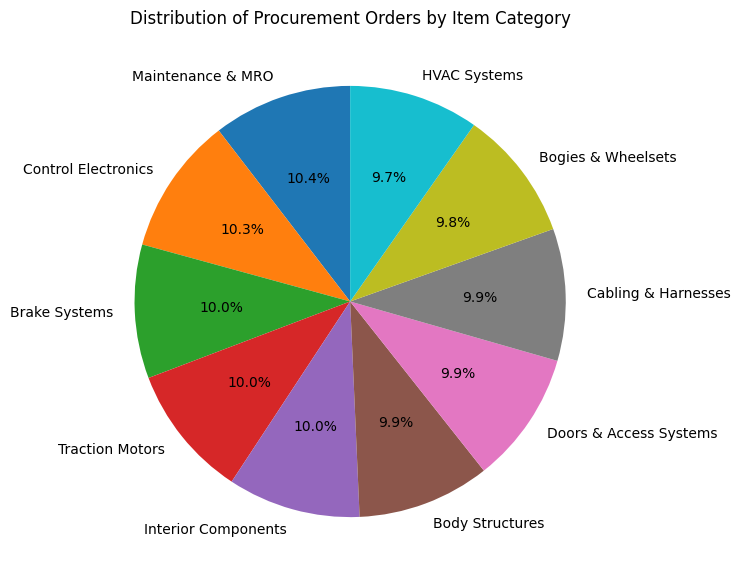

In [40]:
plt.figure(figsize=(7, 7))

plt.pie(
    item_category["Number of Orders"],
    labels=item_category.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribution of Procurement Orders by Item Category")

plt.show()

### Interpretation

Procurement activity is evenly distributed across the ten purchasing categories represented in the dataset.

No single category dominates purchasing demand, indicating that procurement operations cover a diverse range of products and components.

This balanced distribution provides representative business coverage and supports a comprehensive evaluation of procurement performance across different purchasing categories.

## Which suppliers handle the largest share of procurement activity?

Understanding how purchase orders are distributed across suppliers helps identify the organization's most active vendors.

This analysis provides an initial view of supplier concentration and highlights whether procurement activities are evenly distributed or rely heavily on a limited number of suppliers.

In [42]:
supplier_orders = (
    procurement_df["Supplier"]
    .value_counts()
    .rename("Number of Orders")
    .to_frame()
)

supplier_orders["Percentage (%)"] = (
    supplier_orders["Number of Orders"]
    / len(procurement_df)
    * 100
).round(1)

supplier_orders.head(10)

,Number of Orders,Percentage (%)
Supplier,,
ProParts,232,2.3
RailOptima,225,2.2
RailVector,225,2.2
MotionTech,223,2.2
ElectroRail,221,2.2
CoreParts,220,2.2
RailDynamics+,219,2.2
RailLink,218,2.2
PrimeRail,213,2.1


### Interpretation

Procurement activity is broadly distributed across the supplier portfolio.

No individual supplier accounts for a disproportionately large share of purchase orders, suggesting that procurement activities are not concentrated on a limited number of vendors.

This balanced distribution reduces dependency on individual suppliers and provides a representative basis for comparing supplier performance throughout the subsequent analyses.

## How Does Supplier Performance Vary Across Procurement KPIs?

Procurement performance cannot be assessed solely by the number of purchase orders assigned to each supplier. A comprehensive evaluation also considers operational KPIs such as compliance, delivery performance, product quality and cost efficiency.

The following analyses compare suppliers across key procurement indicators to identify operational strengths, potential risks and opportunities for performance improvement.

## Which Suppliers Achieve the Highest Compliance Rate?

Supplier compliance is a key procurement KPI, reflecting how consistently suppliers meet contractual and operational expectations.

Comparing compliance rates across suppliers helps identify reliable business partners while highlighting suppliers that may require closer monitoring or performance improvement initiatives.

In [43]:
supplier_compliance = (
    procurement_df
    .groupby("Supplier")["Compliance"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .unstack()
    [[1]]  # 1 = compliant
    .rename(columns={1: "Compliance Rate (%)"})
    .sort_values("Compliance Rate (%)", ascending=False)
)

supplier_compliance.head(10)

Compliance,Compliance Rate (%)
Supplier,
RailWorks,87.8
IndusRail,84.8
RailDynamics,84.5
ProParts,83.6
RailMaster,83.4
ElectroRail,82.4
IndusPrime,82.1
ElectroParts,82.0
MechaPrime,81.7


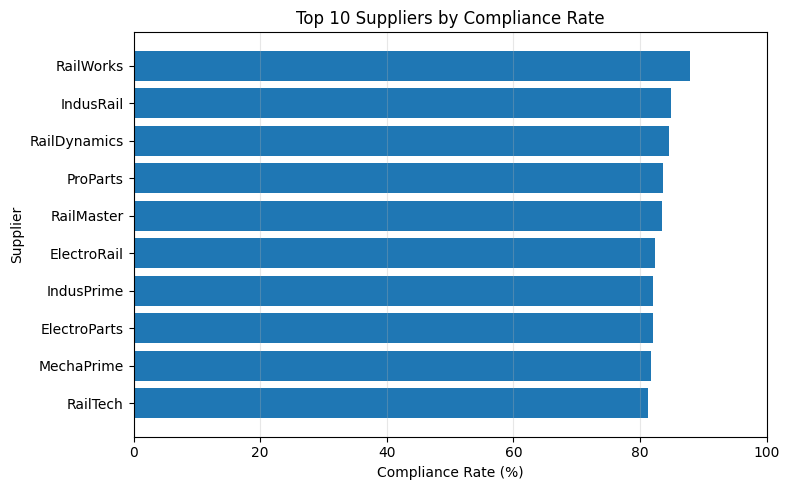

In [54]:
top_suppliers = supplier_compliance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_suppliers.index,
    top_suppliers["Compliance Rate (%)"]
)

plt.xlabel("Compliance Rate (%)")
plt.ylabel("Supplier")
plt.title("Top 10 Suppliers by Compliance Rate")

plt.xlim(0,100)

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

Compliance performance varies across the supplier portfolio, although the highest-performing suppliers consistently achieve compliance rates above 80%.

The observed differences indicate that supplier compliance remains an important procurement KPI for distinguishing operational performance and identifying suppliers that may require closer monitoring.

These results support the use of supplier compliance as a key indicator for procurement performance assessment throughout the remainder of the analysis.

## How Do Order Statuses Vary Across Suppliers?

Order status provides an operational view of supplier execution by indicating whether purchase orders are delivered, pending, partially delivered or cancelled.

Comparing order status distributions across suppliers helps identify differences in operational reliability and highlights suppliers that may require closer performance monitoring.

In [46]:
supplier_order_status = (
    pd.crosstab(
        procurement_df["Supplier"],
        procurement_df["Order_Status"],
        normalize="index"
    )
    * 100
).round(1)

supplier_order_status.head(10)

Order_Status,Cancelled,Delivered,Partially Delivered,Pending
Supplier,,,,
Alpha Inc,3.3,73.5,9.4,13.8
Alstraileco,2.8,71.1,9.4,16.7
Beta Supplies,3.9,66.8,9.8,19.5
CoreParts,1.8,73.2,9.5,15.5
Delta Logistics,5.0,74.1,6.5,14.4
ElectroParts,4.9,69.3,8.3,17.6
ElectroRail,0.5,71.9,11.8,15.8
Epsilon Group,2.1,75.4,10.3,12.3
EuroParts,3.6,71.8,9.2,15.4


### Interpretation

Most suppliers exhibit a similar distribution of delivered, pending, partially delivered and cancelled purchase orders.

Although minor differences exist, the overall results suggest relatively consistent operational performance across the supplier portfolio.

This comparison provides a useful baseline for evaluating supplier reliability alongside additional procurement KPIs such as compliance, delivery lead time and product quality.

## Which Purchasing Categories Represent the Largest Procurement Spend?

Understanding how procurement expenditure is distributed across purchasing categories helps identify where the organization allocates the largest share of its procurement budget.

Using negotiated purchase prices and ordered quantities, this analysis estimates procurement spend by category and highlights the areas representing the greatest financial commitment.

In [57]:
procurement_df["Estimated_Spend"] = (
    procurement_df["Quantity"]
    * procurement_df["Negotiated_Price"]
)

category_spend = (
    procurement_df
    .groupby("Item_Category")["Estimated_Spend"]
    .sum()
    .sort_values(ascending=False)
    .rename("Estimated Procurement Spend")
    .to_frame()
)

category_spend_display = category_spend.copy()

category_spend_display["Estimated Procurement Spend"] = (
    category_spend_display["Estimated Procurement Spend"] / 1_000_000
).round(1)

category_spend_display = category_spend_display.rename(
    columns={"Estimated Procurement Spend": "Estimated Spend (Millions)"}
)

category_spend_display

,Estimated Spend (Millions)
Item_Category,
Traction Motors,51.9
Brake Systems,51.8
Maintenance & MRO,50.2
Doors & Access Systems,50.0
Body Structures,49.5
Interior Components,49.1
Control Electronics,48.9
Bogies & Wheelsets,47.7
Cabling & Harnesses,47.4


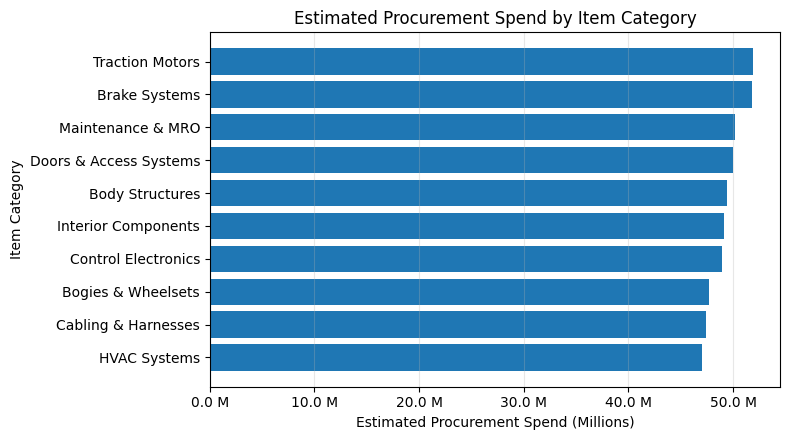

In [62]:
import matplotlib.ticker as mtick

plt.figure(figsize=(8, 4.5))

plt.barh(
    category_spend.index,
    category_spend["Estimated Procurement Spend"] / 1_000_000  # convert to millions
)

plt.xlabel("Estimated Procurement Spend (Millions)")
plt.ylabel("Item Category")
plt.title("Estimated Procurement Spend by Item Category")

ax = plt.gca()
ax.invert_yaxis()

# Format ticks as millions
ax.xaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f M'))

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

Estimated procurement spend is relatively balanced across the ten purchasing categories represented in the dataset.

Traction Motors and Brake Systems account for the highest procurement expenditure, while HVAC Systems represents the lowest total spend. However, the differences between categories remain moderate, indicating that procurement investments are distributed across multiple strategic purchasing areas rather than concentrated in a single category.

Overall, the spending profile suggests a diversified procurement portfolio, providing a suitable foundation for comparing supplier performance and identifying opportunities for cost optimization in the following analyses.

## How are procurement KPIs related?

Understanding the relationships between procurement KPIs helps identify how operational and financial variables evolve together.

Correlation analysis does not establish causality, but it highlights variables that tend to move in the same direction and provides valuable business context before building predictive models.

In [63]:
correlation_df = procurement_df[
    [
        "Quantity",
        "Unit_Price",
        "Negotiated_Price",
        "Defective_Units",
        "Estimated_Spend"
    ]
]

correlation_matrix = correlation_df.corr(numeric_only=True)

correlation_matrix

,Quantity,Unit_Price,Negotiated_Price,Defective_Units,Estimated_Spend
Quantity,1.000000,-0.013121,-0.009589,0.659755,0.641608
Unit_Price,-0.013121,1.000000,0.966677,-0.004663,0.635231
Negotiated_Price,-0.009589,0.966677,1.000000,0.002033,0.660953
Defective_Units,0.659755,-0.004663,0.002033,1.000000,0.428301
Estimated_Spend,0.641608,0.635231,0.660953,0.428301,1.000000


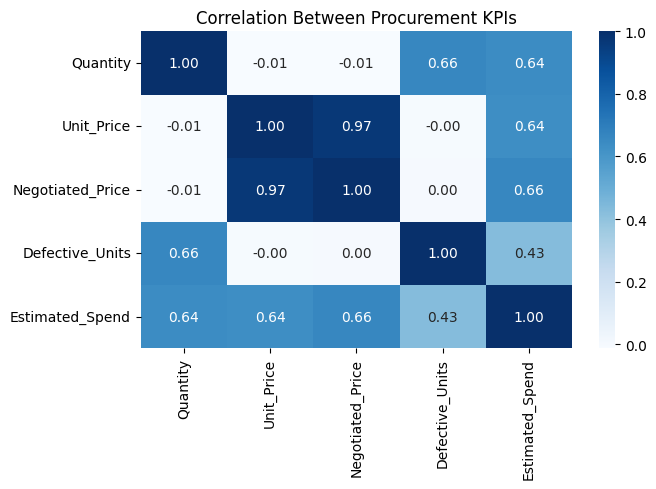

In [66]:
plt.figure(figsize=(7,5))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Between Procurement KPIs")

plt.tight_layout()
plt.show()

The correlation analysis highlights several meaningful relationships between procurement KPIs.

As expected, Unit Price and Negotiated Price exhibit a very strong positive correlation (0.97), indicating that negotiated prices closely follow the original purchase price while reflecting the discounts obtained during supplier negotiations.

Estimated Spend is moderately correlated with Quantity (0.64), Unit Price (0.64) and Negotiated Price (0.66). This confirms that procurement expenditure is primarily driven by both the purchasing volume and the negotiated commercial conditions.

A moderate positive correlation (0.66) is also observed between Quantity and Defective Units. This suggests that suppliers delivering larger order volumes naturally generate a higher number of defective units in absolute terms, although this does not necessarily imply lower product quality.

Overall, the analysis shows that procurement expenditure is mainly associated with commercial variables, while quality indicators exhibit weaker relationships with procurement costs. These insights provide useful business context before identifying the variables that will contribute to the predictive model.

# Implications for Machine Learning

The exploratory analysis confirms that the procurement dataset is complete, consistent and suitable for predictive modeling.

At the end of this notebook, the enriched dataset is exported to the project's `data/processed` directory. This processed dataset will serve as the input for **Notebook 03 — Predictive Modeling**, where feature engineering, model training and supplier compliance prediction will be developed.

Saving the processed dataset ensures a reproducible workflow and clearly separates exploratory analysis from the machine learning stage.

In [67]:
os.makedirs("../data/processed", exist_ok=True)

procurement_df.to_csv(
    "../data/processed/procurement_processed.csv",
    index=False
)

print("Dataset saved to ../data/processed/procurement_processed.csv")

Dataset saved to ../data/processed/procurement_processed.csv


# Conclusion

This exploratory analysis provided a comprehensive understanding of the procurement dataset from both business and analytical perspectives.

The dataset was found to be complete and consistent, allowing reliable analysis of procurement activities, supplier performance and purchasing expenditure.

The analyses identified meaningful differences in supplier compliance, operational performance and procurement spending while highlighting the relationships between key procurement KPIs.

These findings establish the business context required for the next stage of the project, where the dataset will be prepared for feature engineering and predictive modeling.